Dataset Extracted Successfully

Classes Found:
['normal', 'stain', 'dent', 'scratch']

Number of Classes: 4

Images Per Class:
{'normal': 120, 'stain': 120, 'dent': 120, 'scratch': 120}


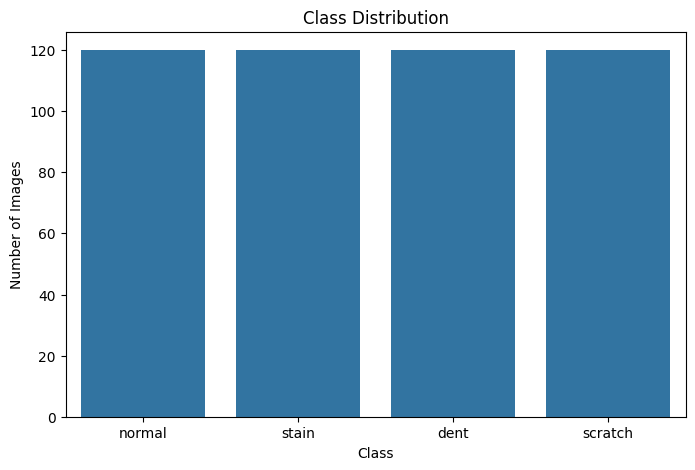

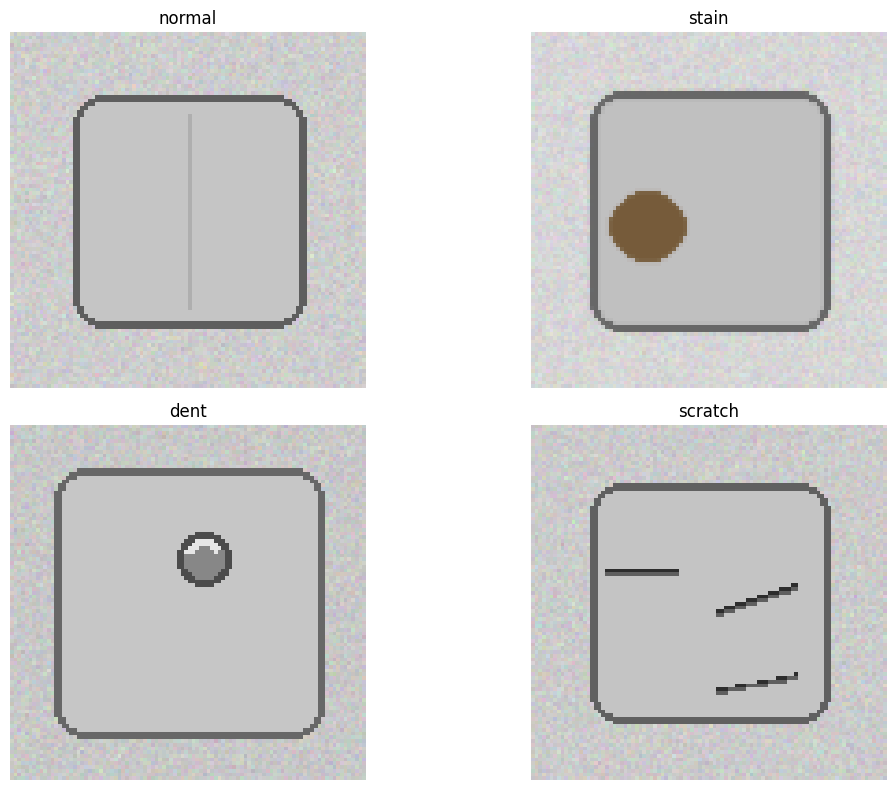


Sample Image Shape: (96, 96, 3)

Dataset Shape: (480, 128, 128, 3)
Labels Shape: (480,)

Training Shape: (384, 128, 128, 3)
Testing Shape: (96, 128, 128, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 963ms/step - accuracy: 0.2292 - loss: 1.8150 - val_accuracy: 0.3021 - val_loss: 1.3876
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 996ms/step - accuracy: 0.2474 - loss: 1.3855 - val_accuracy: 0.2604 - val_loss: 1.3839
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.2865 - loss: 1.3765 - val_accuracy: 0.2292 - val_loss: 1.3759
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3906 - loss: 1.3461 - val_accuracy: 0.4271 - val_loss: 1.2956
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 988ms/step - accuracy: 0.4427 - loss: 1.2614 - val_accuracy: 0.6458 - val_loss: 1.1006
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 877ms/step - accuracy: 0.6068 - loss: 1.0511 - val_accuracy: 0.7812 - val_loss: 0.8822
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.5885 - loss: 0.9424 - val_accuracy: 0.7500 - val_loss: 0.7635
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6406 - loss: 0.8208 - val_accuracy: 0.6354

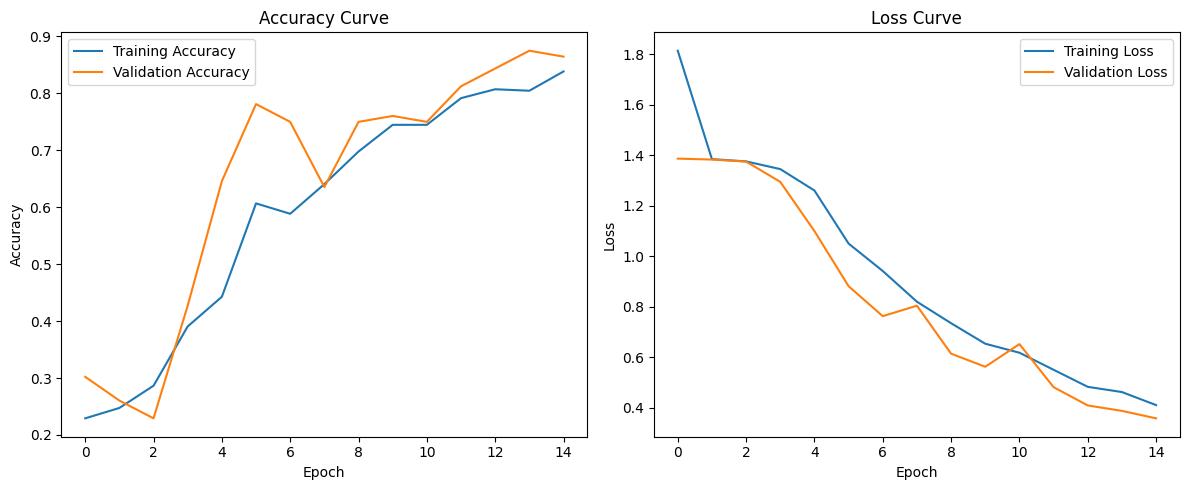

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step - accuracy: 0.8646 - loss: 0.3588

Testing Loss: 0.35882076621055603
Testing Accuracy: 0.8645833134651184
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 391ms/step


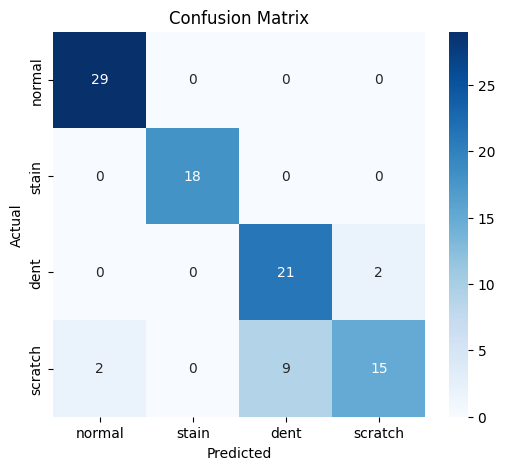


Classification Report:

              precision    recall  f1-score   support

      normal       0.94      1.00      0.97        29
       stain       1.00      1.00      1.00        18
        dent       0.70      0.91      0.79        23
     scratch       0.88      0.58      0.70        26

    accuracy                           0.86        96
   macro avg       0.88      0.87      0.86        96
weighted avg       0.88      0.86      0.86        96



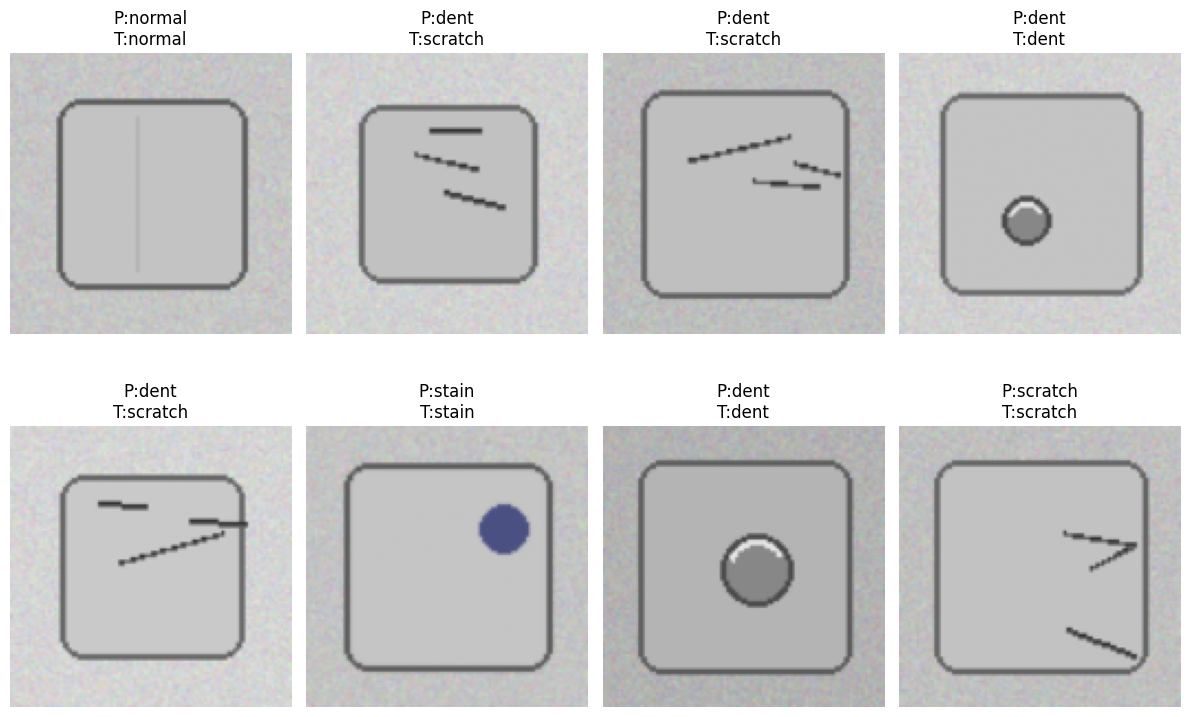


CNN Computer Vision Project Completed Successfully


In [1]:
# ============================================================
# PART 2 - CNN COMPUTER VISION MINI PROJECT
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import os
import zipfile
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

# ============================================================
# EXTRACT DATASET
# ============================================================

with zipfile.ZipFile('/content/images.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset Extracted Successfully")

# ============================================================
# DATASET PATH
# ============================================================

dataset_path = '/content/images'

# ============================================================
# GET CLASSES
# ============================================================

classes = [
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, folder))
]

print("\nClasses Found:")
print(classes)

print("\nNumber of Classes:", len(classes))

# ============================================================
# IMAGE COUNT
# ============================================================

image_count = {}

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    image_count[class_name] = len(os.listdir(class_path))

print("\nImages Per Class:")
print(image_count)

# ============================================================
# CLASS DISTRIBUTION
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=list(image_count.keys()),
    y=list(image_count.values())
)

plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')

plt.show()

# ============================================================
# SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(12,8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis('off')

plt.tight_layout()

plt.show()

print("\nSample Image Shape:", image.shape)

# ============================================================
# IMAGE PREPROCESSING
# ============================================================

img_size = 128

X = []
y = []

for class_index, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        image = cv2.imread(image_path)

        image = cv2.resize(image, (img_size, img_size))

        X.append(image)

        y.append(class_index)

# ============================================================
# NUMPY ARRAYS
# ============================================================

X = np.array(X)
y = np.array(y)

print("\nDataset Shape:", X.shape)
print("Labels Shape:", y.shape)

# ============================================================
# NORMALIZATION
# ============================================================

X = X / 255.0

# ============================================================
# ONE HOT ENCODING
# ============================================================

y = to_categorical(y)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# ============================================================
# DATA AUGMENTATION
# ============================================================

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

# ============================================================
# CNN MODEL
# ============================================================

model = Sequential()

model.add(Input(shape=(128,128,3)))

# ============================================================
# CONVOLUTION BLOCK 1
# ============================================================

model.add(Conv2D(
    32,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D((2,2)))

# ============================================================
# CONVOLUTION BLOCK 2
# ============================================================

model.add(Conv2D(
    64,
    (3,3),
    activation='relu'
))

model.add(MaxPooling2D((2,2)))

# ============================================================
# FLATTEN
# ============================================================

model.add(Flatten())

# ============================================================
# DENSE LAYER
# ============================================================

model.add(Dense(
    128,
    activation='relu'
))

# ============================================================
# DROPOUT
# ============================================================

model.add(Dropout(0.5))

# ============================================================
# OUTPUT LAYER
# ============================================================

model.add(Dense(
    len(classes),
    activation='softmax'
))

# ============================================================
# COMPILE MODEL
# ============================================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# MODEL SUMMARY
# ============================================================

model.summary()

# ============================================================
# TRAIN MODEL
# ============================================================

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,
    validation_data=(X_test, y_test)
)

# ============================================================
# CREATE RESULTS FOLDER
# ============================================================

os.makedirs('results', exist_ok=True)

# ============================================================
# ACCURACY + LOSS CURVES
# ============================================================

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.tight_layout()

plt.savefig(
    'results/accuracy_loss_curves.png',
    dpi=300,
    bbox_inches='tight'
)

print("\naccuracy_loss_curves.png saved successfully")

plt.show()

# ============================================================
# MODEL EVALUATION
# ============================================================

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTesting Loss:", loss)
print("Testing Accuracy:", accuracy)

# ============================================================
# PREDICTIONS
# ============================================================

predictions = model.predict(X_test)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(y_test, axis=1)

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.savefig(
    'results/confusion_matrix.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:\n")

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=classes
))

# ============================================================
# SAMPLE PREDICTIONS
# ============================================================

os.makedirs('sample_predictions', exist_ok=True)

plt.figure(figsize=(12,8))

for i in range(8):

    plt.subplot(2,4,i+1)

    plt.imshow(X_test[i])

    predicted_label = classes[predicted_classes[i]]

    true_label = classes[true_classes[i]]

    plt.title(
        f"P:{predicted_label}\nT:{true_label}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig(
    'sample_predictions/prediction_outputs.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# ============================================================
# FINAL MESSAGE
# ============================================================

print("\nCNN Computer Vision Project Completed Successfully")